# Analyze difference between current headroom and projected electric grid load

This notebook analyzes the difference between the hosting capacity calculated utilizing current ICA data and projected electricity needs in California at the census tract level. The projected load data contains the 2020 census tract data while the calculated hosting capacity data utilizes the 2025 census tract data. To match these dataset a spatial join is utilized.

In [83]:
# load libraries
import pandas as pd 
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import PowerNorm, LogNorm
from matplotlib.colors import TwoSlopeNorm

In [2]:
# load in data
projected_load = pd.read_csv('/../../capstone/electrigrid/data/projected_load/tract_scenario_comparison.csv')
tract_summary = pd.read_csv('/../../capstone/electrigrid/data/projected_load/tract_summary.csv')
sce_hostcap = gpd.read_parquet('/../../capstone/electrigrid/data/census_hosting_capacity/sce_census_map_new.parquet')
pge_hostcap = gpd.read_parquet('/../../capstone/electrigrid/data/census_hosting_capacity/pge_census_map_new.parquet')
sdge_hostcap = gpd.read_parquet('/../../capstone/electrigrid/data/census_hosting_capacity/sdge_census_map_new.parquet')
census2020 = gpd.read_file('/../../capstone/electrigrid/data/census/censustract2020/tl_2020_06_tract.shp')
iou_shapes = gpd.read_file('/../../capstone/electrigrid/data/utilities/IOU_shapefiles.geojson')
ca_boundary = gpd.read_file('/../../capstone/electrigrid/data/ca_state_boundary.geojson')

# Investigate the tract summary data

In [3]:
tract_summary

,tract_id,scenario,annual_heating,peak_heating,peak_hour_heating,annual_cooling,peak_cooling,peak_hour_cooling,annual_hvac,peak_hvac,...,monthly_average_peak_exports_m03,monthly_average_peak_exports_m04,monthly_average_peak_exports_m05,monthly_average_peak_exports_m06,monthly_average_peak_exports_m07,monthly_average_peak_exports_m08,monthly_average_peak_exports_m09,monthly_average_peak_exports_m10,monthly_average_peak_exports_m11,monthly_average_peak_exports_m12
0,101050101,baseline,2355214.704,2472.808,1303,6637557.742,5576.662,4936,9.049241e+06,5590.470,...,1450.209626,1833.681377,1925.371581,1700.288787,1331.944806,1490.284293,1598.494210,1495.433939,969.630944,856.646095
1,101050102,baseline,2270635.655,2225.642,1303,3836218.190,3429.123,4936,6.142196e+06,3437.887,...,565.807475,727.653351,776.119432,698.827671,563.063739,613.761342,654.739613,603.548389,383.965592,327.047146
2,101050201,baseline,1507129.516,1523.182,1278,2876298.696,2485.575,4936,4.408875e+06,2496.747,...,158.370717,198.168605,210.526255,188.158894,150.604208,165.391451,176.539408,161.680260,100.981237,88.425195
3,101050202,baseline,2591524.081,2324.490,1272,3525976.409,3128.553,4936,6.146741e+06,3139.377,...,131.507766,164.269276,173.048946,153.991553,122.185436,135.593279,144.068135,134.811911,85.319428,74.025202
4,101050301,baseline,1062507.516,1051.209,1277,2414380.377,2237.497,4936,3.496785e+06,2242.501,...,593.455756,741.788015,773.607302,673.806714,524.436341,590.561161,640.429973,603.156111,394.726014,356.693877
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18079,99003906,high,1719231.308,2243.824,1302,4207000.506,3211.390,4936,5.964284e+06,3223.346,...,383.247966,665.251178,690.472134,523.604513,194.230573,300.051751,371.564583,387.353959,185.448970,60.907252
18080,99003907,high,2398806.229,3365.878,1303,9396687.363,7891.053,4936,1.185637e+07,7913.257,...,964.646567,1595.539565,1621.402697,1147.501466,450.938790,662.854387,799.109324,868.029848,488.027393,226.569533
18081,99003908,high,1068847.430,1314.966,1303,2001602.833,1646.402,4936,3.090531e+06,1654.150,...,200.699913,367.139869,396.191972,327.814842,155.414983,216.683595,231.372468,229.347478,87.068210,28.059093
18082,99003909,high,2071215.277,2595.438,1302,7018196.062,5675.536,4936,9.137991e+06,5691.564,...,613.824155,1026.484421,1031.436301,761.895102,351.567681,471.172587,564.965073,597.766374,327.811454,141.318573


The `tract_summary` is the data for the baseline. This won't be used further in this investigation. 

## Investigate Projected Load data

In [4]:
projected_load

,tract_id,annual_heating_baseline,peak_heating_baseline,peak_hour_heating_baseline,annual_cooling_baseline,peak_cooling_baseline,peak_hour_cooling_baseline,annual_hvac_baseline,peak_hvac_baseline,peak_hour_hvac_baseline,...,pct_increase_monthly_average_peak_exports_m03,pct_increase_monthly_average_peak_exports_m04,pct_increase_monthly_average_peak_exports_m05,pct_increase_monthly_average_peak_exports_m06,pct_increase_monthly_average_peak_exports_m07,pct_increase_monthly_average_peak_exports_m08,pct_increase_monthly_average_peak_exports_m09,pct_increase_monthly_average_peak_exports_m10,pct_increase_monthly_average_peak_exports_m11,pct_increase_monthly_average_peak_exports_m12
0,101050101,2355214.704,2472.808,1303,6637557.742,5576.662,4936,9.049241e+06,5590.470,4936,...,45.124032,59.776797,62.726066,54.604039,30.887606,38.191827,39.879113,38.829196,20.096738,9.059913
1,101050102,2270635.655,2225.642,1303,3836218.190,3429.123,4936,6.142196e+06,3437.887,4936,...,62.475768,82.018839,83.649028,69.599404,30.042981,45.787471,53.004921,55.495222,27.575736,9.307794
2,101050201,1507129.516,1523.182,1278,2876298.696,2485.575,4936,4.408875e+06,2496.747,4936,...,148.455989,191.512217,194.126877,167.827969,82.771258,116.739782,137.229268,140.855593,82.776129,50.921550
3,101050202,2591524.081,2324.490,1272,3525976.409,3128.553,4936,6.146741e+06,3139.377,4936,...,195.809506,250.741196,254.917695,211.899277,85.462427,138.467900,175.994677,185.914195,103.194909,57.780798
4,101050301,1062507.516,1051.209,1277,2414380.377,2237.497,4936,3.496785e+06,2242.501,4936,...,41.179062,53.806938,54.653630,44.065369,23.851800,30.238548,32.918991,33.853377,20.012565,13.345708
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9037,99003906,1567539.817,1675.641,1303,4007163.925,3009.648,4936,5.612756e+06,3021.604,4936,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9038,99003907,1643612.243,1880.696,1303,9027033.800,7425.407,4936,1.073153e+07,7447.611,4936,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9039,99003908,980829.110,1144.821,1303,1899860.020,1496.900,4936,2.900770e+06,1504.648,4936,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9040,99003909,1688330.711,1672.609,1303,6871341.492,5477.952,4936,8.608252e+06,5493.980,4936,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
projected_load.shape

(9042, 209)

There are 209 columns let's see which are the most important for us when looking at projected load data.

In [6]:
# subset for what was included in the readme
projected_load = projected_load[['tract_id', 
                                 'annual_pv_grid_baseline', 
                                 'peak_pv_grid_baseline',
                                 'annual_total_baseline',
                                 'peak_total_baseline',
                                 'annual_net_baseline',
                                 'peak_net_baseline',
                                 'annual_total_high',
                                 'annual_net_high',
                                 'pct_increase_annual_pv_grid',
                                 'p95_daily_peak_total_baseline',
                                 'p95_daily_peak_net_baseline',
                                 'p95_daily_peak_exports_baseline',
                                 'pct_increase_annual_total',
                                 'pct_increase_peak_total',
                                 'pct_increase_annual_net',
                                 'pct_increase_peak_net',
                                 'pct_increase_p95_daily_peak_total',
                                 'pct_increase_p95_daily_peak_net',
                                 'pct_increase_p95_daily_peak_exports']]

In [7]:
projected_load.head()

,tract_id,annual_pv_grid_baseline,peak_pv_grid_baseline,annual_total_baseline,peak_total_baseline,annual_net_baseline,peak_net_baseline,annual_total_high,annual_net_high,pct_increase_annual_pv_grid,p95_daily_peak_total_baseline,p95_daily_peak_net_baseline,p95_daily_peak_exports_baseline,pct_increase_annual_total,pct_increase_peak_total,pct_increase_annual_net,pct_increase_peak_net,pct_increase_p95_daily_peak_total,pct_increase_p95_daily_peak_net,pct_increase_p95_daily_peak_exports
0,101050101,2.959735e+06,2353.013571,2.418041e+07,7541.596242,2.165261e+07,6898.598399,2.569669e+07,2.013312e+07,35.885901,6785.780642,6051.076242,2103.024550,6.270672,5.083126,-7.017575,-7.658958,4.775366,-14.575055,69.942161
1,101050102,1.228744e+06,934.608793,1.478831e+07,4540.656719,1.388782e+07,4329.817895,1.572635e+07,1.324041e+07,44.122090,4047.703895,3758.999385,838.258763,6.343100,7.096314,-4.661723,-6.223291,6.411754,-9.571121,91.817151
2,101050201,3.304704e+05,252.035794,1.068719e+07,3870.539240,1.043091e+07,3814.111310,1.159768e+07,1.027810e+07,110.129063,2987.648443,2906.069323,228.615048,8.519428,4.290516,-1.464980,-2.510222,6.321410,-8.192671,216.261314
3,101050202,2.713197e+05,212.348648,1.334280e+07,4788.374193,1.313129e+07,4706.692714,1.455011e+07,1.312264e+07,133.994954,3675.509865,3600.023866,189.725772,9.048441,5.503752,-0.065857,-0.124648,8.068247,-3.404109,281.915351
4,101050301,1.202807e+06,945.061611,8.804029e+06,2933.921079,7.788774e+06,2702.590338,9.551153e+06,7.461803e+06,32.629535,2599.003287,2333.947411,850.930057,8.486157,8.183152,-4.197976,-0.988236,7.508347,-9.124383,61.359333


In [8]:
print(projected_load['annual_total_high'].min())
print(projected_load['annual_total_high'].max())

9731.136
63425074.50381643


Assumption:  These values are for the entire census tract for all of the households.

## View hosting capacity calculations

### SCE

In [9]:
sce_hostcap.head()

,GEOID,geometry,avg_DER_remain_pv_hh,avg_DER_remain_pv_opflex_hh,avg_DER_remain_generation_hh,avg_DER_remain_generation_opflex_hh,avg_DER_total_generation_hh,avg_DER_remain_load_hh,avg_DER_total_pv_hh,zillow_tract_hh_count
0,06065042516,"POLYGON ((254831.161 -450428.536, 254879.224 -...",2.708275,0.035472,2.446923,0.032614,3.748624,1.162056,4.009977,762.0
1,06065042716,"POLYGON ((252988.226 -477491.812, 253070.244 -...",0.000000,0.000000,0.000000,0.000000,4.142523,0.093296,4.142523,2114.0
2,06065042717,"POLYGON ((253204.987 -475305.031, 253228.177 -...",0.000000,0.000000,0.000000,0.000000,2.839426,0.306908,2.839426,1789.0
3,06065042902,"POLYGON ((245709.226 -466855.471, 245710.230 -...",0.000000,0.000000,0.004193,0.000000,0.736394,2.871458,0.732202,1314.0
4,06065042903,"POLYGON ((244083.685 -461694.249, 244084.463 -...",0.000000,0.000000,0.000000,0.000000,1.052535,0.190597,1.052535,1444.0


In [10]:
sce_hostcap.shape

(5098, 10)

Since the projected data contains the total data for the whole census tract we need to work at the same scale.

In [11]:
# calculate the total headroom for the whole census tract
sce_hostcap['total_DER'] = sce_hostcap['zillow_tract_hh_count'] * sce_hostcap['avg_DER_remain_load_hh']

In [12]:
print(sce_hostcap['total_DER'].min())
print(sce_hostcap['total_DER'].max())

-2468.496970362294
12980.186705068398


### PG&E

In [13]:
pge_hostcap.shape

(3196, 10)

In [14]:
# calculate the total headroom for the whole census tract
pge_hostcap['total_DER'] = pge_hostcap['zillow_tract_hh_count'] * pge_hostcap['avg_DER_remain_load_hh']

### SDG&E

In [15]:
sdge_hostcap.shape

(797, 10)

In [16]:
# calculate the total headroom for the whole census tract
sdge_hostcap['total_DER'] = sdge_hostcap['zillow_tract_hh_count'] * sdge_hostcap['avg_DER_remain_load_hh']

## Convert GEOID of the hosting capacity data to match projected load census tract

The `projected_load` tract removed the initial `06` from the `GEOID` and is numeric dropping any preceeding zeros. 

In [17]:
# remove the unnecessary pre-crusor number from the geoid
sce_hostcap['GEOID'] = sce_hostcap['GEOID'].str[2:]
pge_hostcap['GEOID'] = pge_hostcap['GEOID'].str[2:]
sdge_hostcap['GEOID'] = sdge_hostcap['GEOID'].str[2:]


In [18]:
# change the GEOID to a number so they match load projected
sce_hostcap['GEOID'] = sce_hostcap['GEOID'].astype('int64')
pge_hostcap['GEOID'] = pge_hostcap['GEOID'].astype('int64')
sdge_hostcap['GEOID'] = sdge_hostcap['GEOID'].astype('int64')

In [19]:
# join the dataframes to the projected load
sce_join = pd.merge(sce_hostcap, projected_load, how = "inner", left_on= 'GEOID', right_on='tract_id')
pge_join = pd.merge(pge_hostcap, projected_load, how = "inner", left_on= 'GEOID', right_on='tract_id')
sdge_join = pd.merge(sdge_hostcap, projected_load, how = "inner", left_on= 'GEOID', right_on='tract_id')

## Calculate the difference in the headroom and the projected load

In [20]:
# difference between the projected load and the baseline
sce_join['annual_net_diff'] = sce_join['annual_net_high'] - sce_join['annual_net_baseline']
pge_join['annual_net_diff'] = pge_join['annual_net_high'] - pge_join['annual_net_baseline']
sdge_join['annual_net_diff'] = sdge_join['annual_net_high'] - sdge_join['annual_net_baseline']

# convert the annual_net_diff to kw
sce_join['annual_net_diff_kw'] = sce_join['annual_net_diff'] / 1000
pge_join['annual_net_diff_kw'] = pge_join['annual_net_diff'] / 1000
sdge_join['annual_net_diff_kw'] = sdge_join['annual_net_diff'] / 1000

In [21]:
# calculate the difference between the headroom and the projected load
sce_join['diff_proj_load'] = sce_join['total_DER'] - sce_join['annual_net_diff_kw']
pge_join['diff_proj_load'] = pge_join['total_DER'] - pge_join['annual_net_diff_kw']
sdge_join['diff_proj_load'] = sdge_join['total_DER'] - sdge_join['annual_net_diff_kw']

In [22]:
# save the min and max

# save the range for mapping differences
sce_min_diff = sce_join['diff_proj_load'].min()
sce_max_diff = sce_join['diff_proj_load'].max()

# save the range for mapping differences
pge_min_diff = pge_join['diff_proj_load'].min()
pge_max_diff = pge_join['diff_proj_load'].max()

# save the range for mapping differences
sdge_min_diff = sdge_join['diff_proj_load'].min()
sdge_max_diff = sdge_join['diff_proj_load'].max()

max_diff = max(sce_max_diff, pge_max_diff, sdge_max_diff)
min_diff = min(sce_min_diff, pge_min_diff, sdge_min_diff)

### Convert CRS for mapping 

In [23]:
# set the crs for all
sce_join = sce_join.to_crs('EPSG:6933')
pge_join = pge_join.to_crs('EPSG:6933')
sdge_join = sdge_join.to_crs('EPSG:6933')
ca_boundary = ca_boundary.to_crs('EPSG:6933')

## Prepare IOU boundaries for mapping

In [24]:
# change crs to match other values
iou_shapes = iou_shapes.to_crs('EPSG:6933')

# create shapes for each iou
sce_shape = iou_shapes[iou_shapes['Acronym'] == 'SCE']
pge_shape = iou_shapes[iou_shapes['Acronym'] == 'PG&E']
sdge_shape = iou_shapes[iou_shapes['Acronym'] == "SDG&E"]

In [25]:
pge_join.head()

,GEOID,geometry,avg_DER_remain_pv_hh,avg_DER_remain_pv_opflex_hh,avg_DER_remain_generation_hh,avg_DER_remain_generation_opflex_hh,avg_DER_total_generation_hh,avg_DER_remain_load_hh,avg_DER_total_pv_hh,zillow_tract_hh_count,...,pct_increase_annual_total,pct_increase_peak_total,pct_increase_annual_net,pct_increase_peak_net,pct_increase_p95_daily_peak_total,pct_increase_p95_daily_peak_net,pct_increase_p95_daily_peak_exports,annual_net_diff,annual_net_diff_kw,diff_proj_load
0,85507002,"POLYGON ((-11770247.360 4426729.907, -11770228...",0.368304,0.129625,0.371032,0.101275,5.454829,1.503846,5.452101,534.0,...,12.820095,15.495932,-16.840546,-15.874881,10.948657,-19.175178,210.692852,-1.651515e+06,-1651.514748,2454.568654
1,85504323,"POLYGON ((-11760835.412 4447242.373, -11760824...",3.042006,2.553713,2.494846,1.980096,8.368178,2.124298,8.915339,931.0,...,4.932630,3.814101,-14.217606,-4.704162,3.288081,-17.081742,328.715687,-2.254167e+06,-2254.166816,4231.888484
2,13381000,"POLYGON ((-11805330.011 4501253.208, -11805324...",6.125859,1.813684,6.018260,1.411552,9.919102,0.455655,10.026701,1306.5,...,9.220982,11.833601,-4.943888,-7.619313,10.203076,-12.880583,294.058332,-7.649591e+05,-764.959076,1360.271750
3,85511915,"POLYGON ((-11760903.293 4431135.586, -11760865...",4.408803,9.354565,2.592748,5.508081,10.723265,2.535853,12.539320,673.0,...,6.132742,5.162410,-3.302157,-7.291120,5.221675,-6.295804,511.564949,-3.023184e+05,-302.318363,2008.947437
4,85504322,"POLYGON ((-11761953.979 4447334.033, -11761838...",0.505821,0.141704,0.352065,0.108970,1.687938,1.602737,1.841694,9691.0,...,6.434308,5.489245,-9.578910,-5.782263,6.112346,-11.105859,1228.676011,-1.337478e+06,-1337.478094,16869.602613


In [26]:
sce_join.head()

,GEOID,geometry,avg_DER_remain_pv_hh,avg_DER_remain_pv_opflex_hh,avg_DER_remain_generation_hh,avg_DER_remain_generation_opflex_hh,avg_DER_total_generation_hh,avg_DER_remain_load_hh,avg_DER_total_pv_hh,zillow_tract_hh_count,...,pct_increase_annual_total,pct_increase_peak_total,pct_increase_annual_net,pct_increase_peak_net,pct_increase_p95_daily_peak_total,pct_increase_p95_daily_peak_net,pct_increase_p95_daily_peak_exports,annual_net_diff,annual_net_diff_kw,diff_proj_load
0,65042516,"POLYGON ((-11312413.370 4085454.785, -11312363...",2.708275,0.035472,2.446923,0.032614,3.748624,1.162056,4.009977,762.0,...,7.353559,1.347570,-5.475587,-6.548283,0.505315,-12.892169,194.067065,-4.431536e+05,-443.153598,1328.640569
1,65042716,"POLYGON ((-11315147.995 4059540.484, -11315058...",0.000000,0.000000,0.000000,0.000000,4.142523,0.093296,4.142523,2114.0,...,1.149105,-10.349994,-15.731230,-10.952587,-2.828994,-14.820662,48.545324,-3.291567e+06,-3291.566926,3488.795258
2,65042717,"POLYGON ((-11314857.092 4061635.538, -11314831...",0.000000,0.000000,0.000000,0.000000,2.839426,0.306908,2.839426,1789.0,...,1.005654,3.394804,-13.922215,-0.814884,1.822711,-12.164074,59.143887,-2.533463e+06,-2533.462611,3082.520506
3,65042902,"POLYGON ((-11322407.446 4069953.324, -11322405...",0.000000,0.000000,0.004193,0.000000,0.736394,2.871458,0.732202,1314.0,...,3.008461,2.444278,-8.910648,-6.133404,1.741785,-13.488556,879.095413,-1.121227e+06,-1121.226902,4894.322126
4,65042903,"POLYGON ((-11323950.356 4074948.874, -11323948...",0.000000,0.000000,0.000000,0.000000,1.052535,0.190597,1.052535,1444.0,...,2.782442,1.256712,-10.742170,-2.326507,1.463030,-12.866801,225.489375,-1.470037e+06,-1470.036599,1745.258599


In [27]:
pge_join.dtypes

GEOID                                     int64
geometry                               geometry
avg_DER_remain_pv_hh                    float64
avg_DER_remain_pv_opflex_hh             float64
avg_DER_remain_generation_hh            float64
avg_DER_remain_generation_opflex_hh     float64
avg_DER_total_generation_hh             float64
avg_DER_remain_load_hh                  float64
avg_DER_total_pv_hh                     float64
zillow_tract_hh_count                   float64
total_DER                               float64
tract_id                                  int64
annual_pv_grid_baseline                 float64
peak_pv_grid_baseline                   float64
annual_total_baseline                   float64
peak_total_baseline                     float64
annual_net_baseline                     float64
peak_net_baseline                       float64
annual_total_high                       float64
annual_net_high                         float64
pct_increase_annual_pv_grid             

## Transform the difference values

Use the log-modulus tranformation instead of just log since the data contains negative numbers and log can't handle negative numbers.

In [42]:
# transform the difference values with the log-modulus transformation
pge_join['transformed_diff_proj_load'] = np.sign(pge_join['diff_proj_load']) * np.log1p(np.abs(pge_join['diff_proj_load']))
sce_join['transformed_diff_proj_load'] = np.sign(sce_join['diff_proj_load']) * np.log1p(np.abs(sce_join['diff_proj_load']))
sdge_join['transformed_diff_proj_load'] = np.sign(sdge_join['diff_proj_load']) * np.log1p(np.abs(sdge_join['diff_proj_load']))

# Map the differences

In [77]:
# concat all of the dataframes to make one visual
iou_projected = gpd.GeoDataFrame(pd.concat([sce_join, pge_join]), crs = sce_join.crs)
iou_projected = gpd.GeoDataFrame(pd.concat([iou_projected, sdge_join]), crs = sdge_join.crs)

In [78]:
# add a norm scaler to the plots
iou_norm = PowerNorm(gamma=0.4, vmin=iou_projected['diff_proj_load'].min(), vmax=iou_projected['diff_proj_load'].max())

In [87]:
vmin = iou_projected['diff_proj_load'].quantile(0.05)
vmax = iou_projected['diff_proj_load'].quantile(0.95)

norm = TwoSlopeNorm(vcenter=0, vmin=vmin, vmax=vmax)

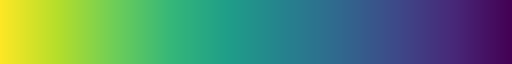

In [29]:
custom_colors = [
"#fde725",
"#b5de2b",
"#6ece58",
"#35b779",
"#1f9e89",
"#26828e",
"#31688e",
"#3e4989",
"#482878",
"#440154"
]

# create a ListedColormap
custom_cmap = LinearSegmentedColormap.from_list("custom_gradient", custom_colors)
custom_cmap

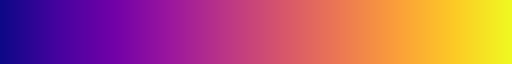

In [30]:
custom_colors2 = [
    "#0d0887",
    "#46039f",
    "#7201a8",
    "#9c179e",
    "#bd3786",
    "#d8576b",
    "#ed7953",
    "#fb9f3a",
    "#fdca26",
    "#f0f921",
]

# create a ListedColormap
custom_cmap2 = LinearSegmentedColormap.from_list("custom_gradient", custom_colors2)
custom_cmap2

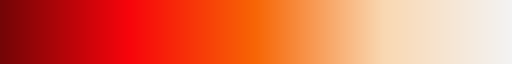

In [67]:
custom_orange = [
    "#730606",
    "#F7040C",
    "#F76605",
    "#FAD8B2",
   "#F3F3F3"
]

# create a ListedColormap
orange_cmap = LinearSegmentedColormap.from_list("custom_gradient", custom_orange)
orange_cmap

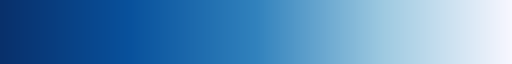

In [69]:
custom_blues = [
    "#08306B",  # deep navy (low)
    "#08519C",  # dark blue
    "#3182BD",  # medium blue
    "#9ECAE1",  # light blue
    "#F7F7FF",  # near white (high)
]

# create a ListedColormap
blues_cmap = LinearSegmentedColormap.from_list("custom_gradient", custom_blues)
blues_cmap

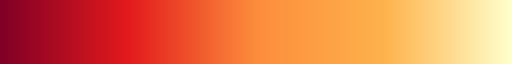

In [71]:
custom_electric = [
    "#800026",  # dark crimson (low)
    "#E31A1C",  # red
    "#FD8D3C",  # orange
    "#FEB24C",  # amber
    "#FFFFCC",  # pale yellow (high)
]

# create a ListedColormap
electric_cmap = LinearSegmentedColormap.from_list("custom_gradient", custom_electric)
electric_cmap


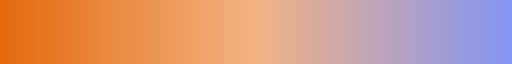

In [100]:
two_col = [
    "#E46A0D",
    "#F3B484",
    "#8495F3"
]


# create a ListedColormap
twocol_cmap = LinearSegmentedColormap.from_list("custom_gradient", two_col)
twocol_cmap

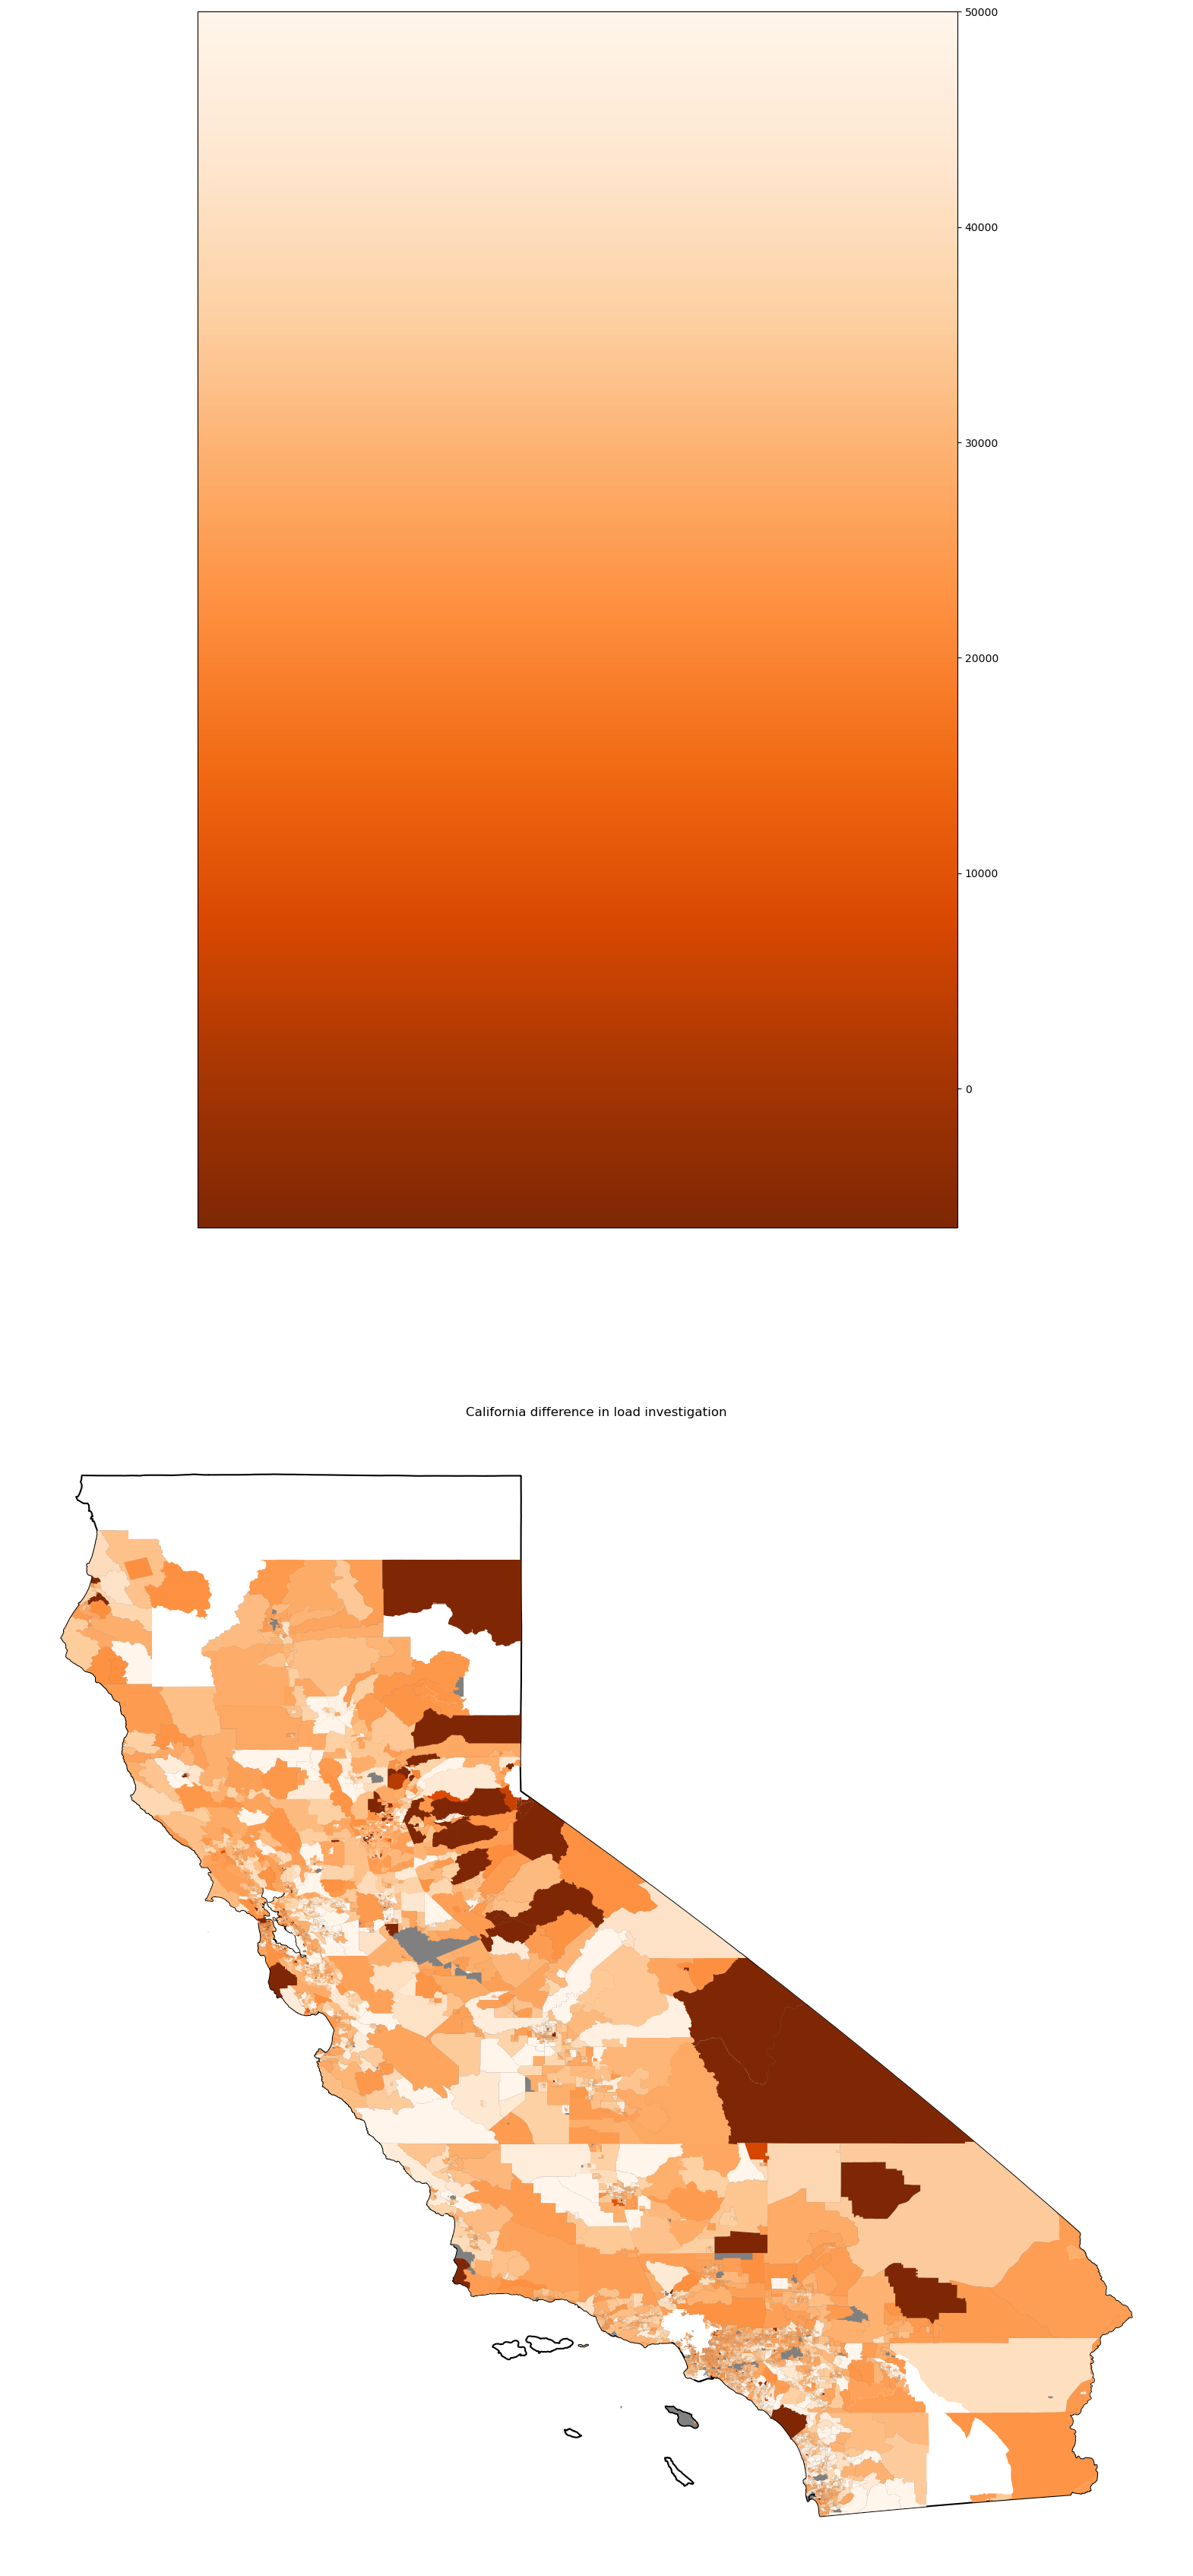

In [102]:
fig, ax = plt.subplots(figsize = (20, 20))
ax.axis('off')

cmap = plt.get_cmap('Oranges')
oranges_reversed = cmap.reversed()

ca_boundary.geometry.boundary.plot(ax = ax,
                 zorder = 1, 
                 color = 'black',
                 linewidth = 1.5)

pge_shape.plot(ax = ax,
               zorder = 2,
               color = 'grey')

sce_shape.plot(ax = ax,
               zorder = 3,
               color = 'grey')

sdge_shape.plot(ax = ax, 
           zorder = 4,
           color = 'grey')

iou_projected.plot('diff_proj_load',
          ax = ax,
          zorder = 5,
          cmap = oranges_reversed, 
          norm = norm)



plt.title('California difference in load investigation')

# Add shared colorbar at the bottom
sm = plt.cm.ScalarMappable(norm=plt.Normalize(vmin= min_diff, vmax=max_diff), cmap = oranges_reversed)
cbar_ax = fig.add_axes([0.25, 1, 0.5, 0.8])  # [left, bottom, width, height]
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='vertical')
# cbar.set_label('Difference in load to projected load')

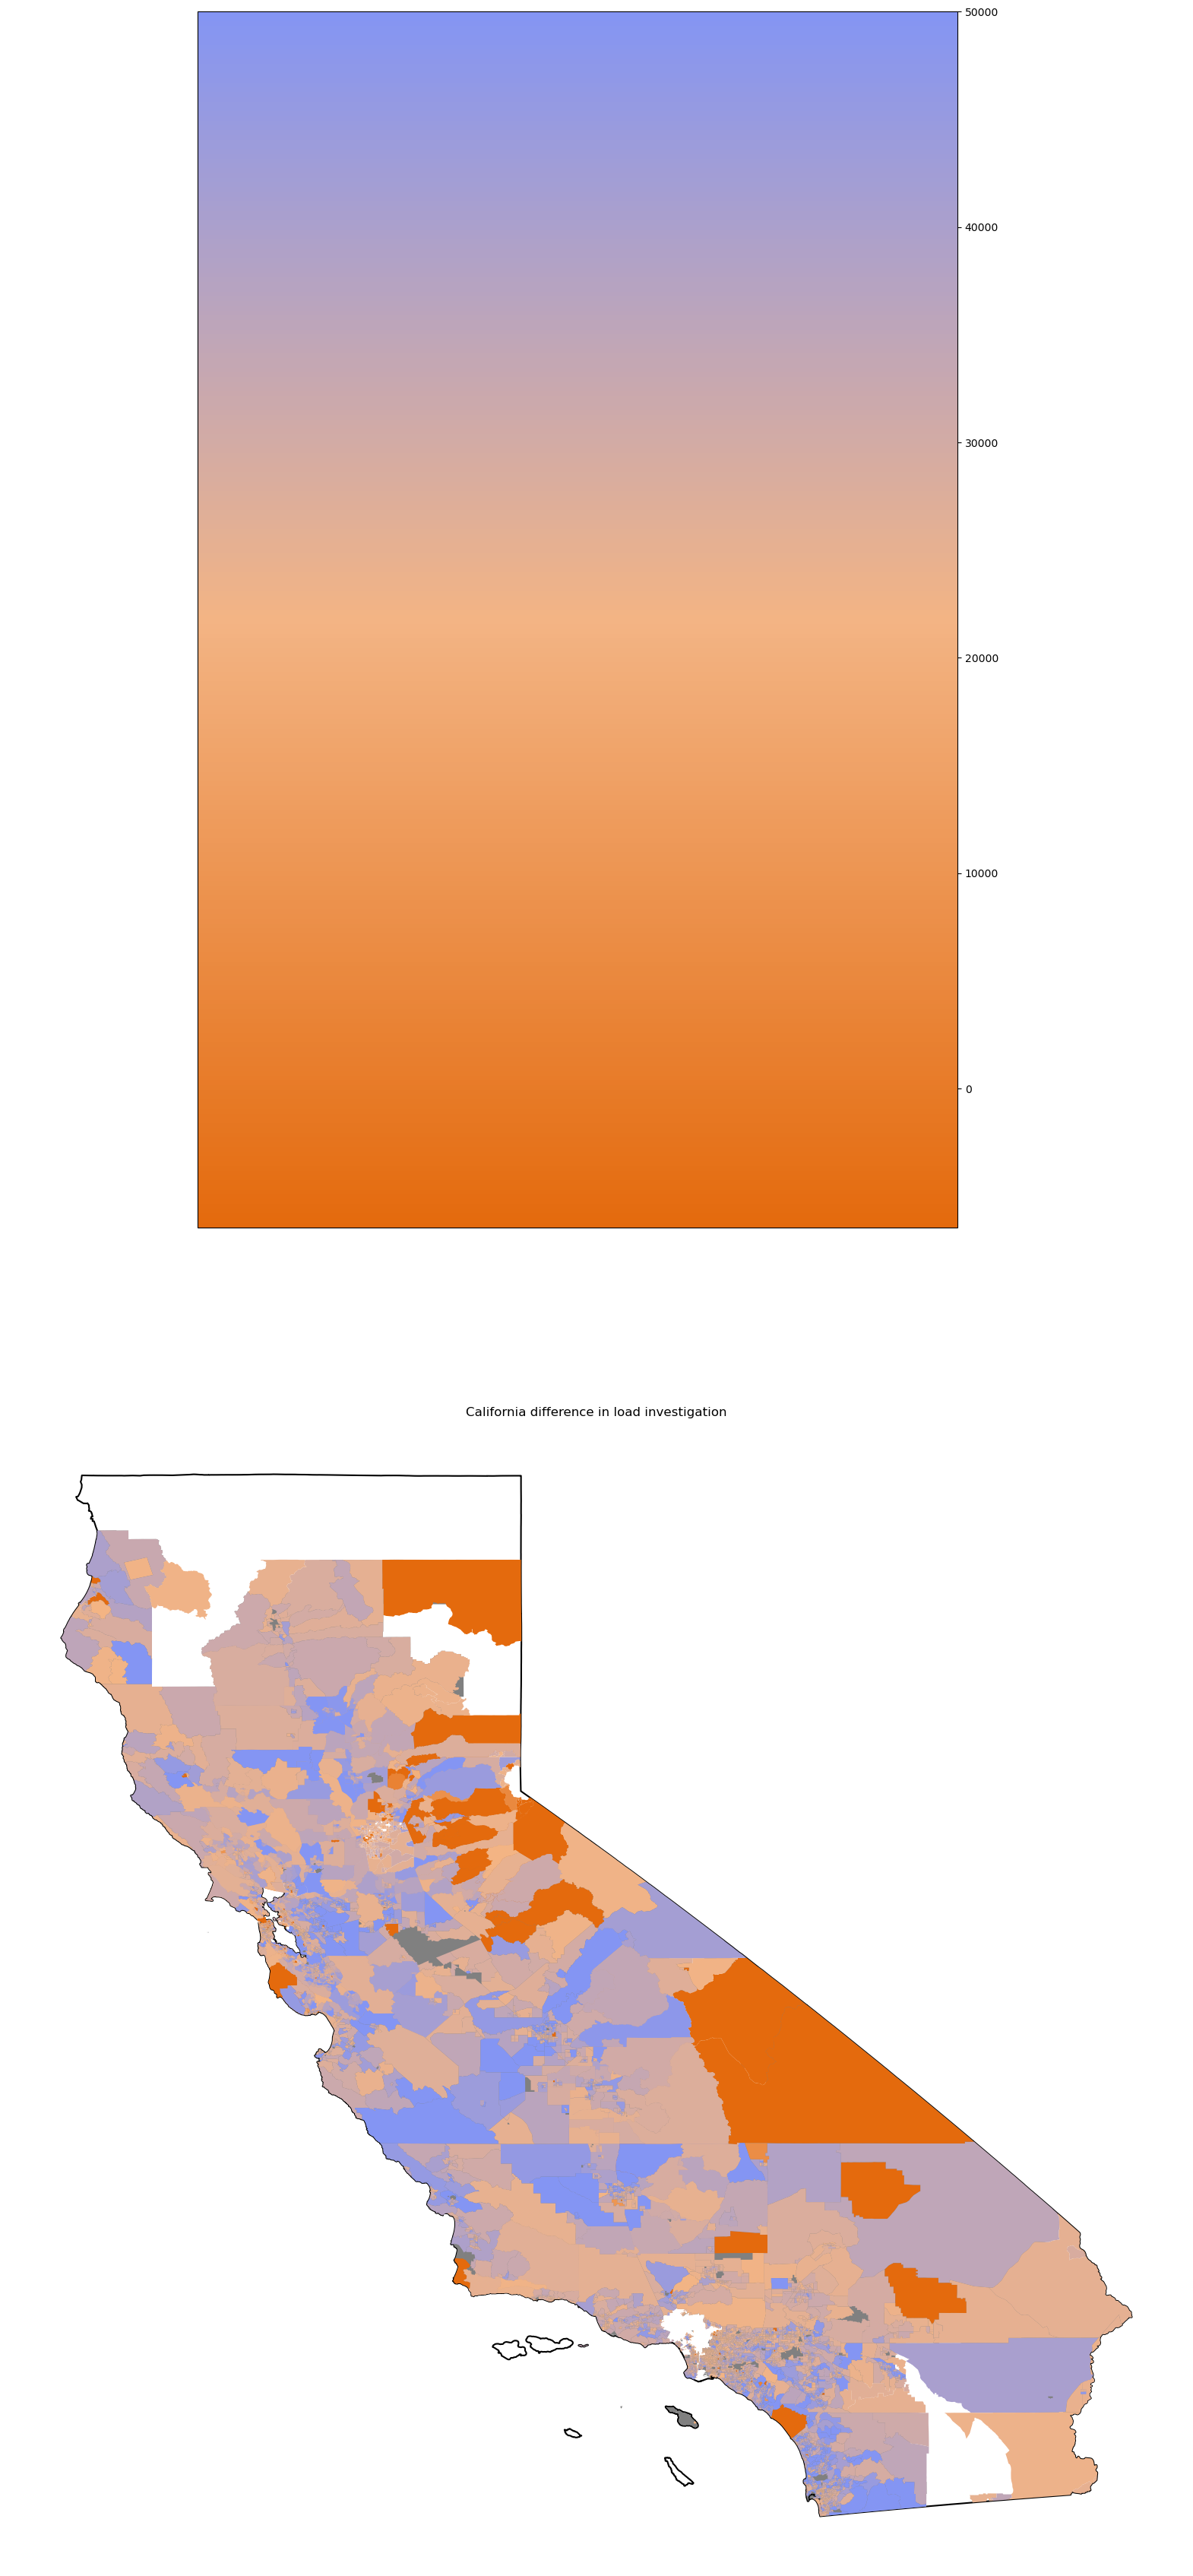

In [101]:
fig, ax = plt.subplots(figsize = (20, 20))
ax.axis('off')

# cmap = plt.get_cmap('Oranges')
# oranges_reversed = cmap.reversed()

ca_boundary.geometry.boundary.plot(ax = ax,
                 zorder = 1, 
                 color = 'black',
                 linewidth = 1.5)

pge_shape.plot(ax = ax,
               zorder = 2,
               color = 'grey')

sce_shape.plot(ax = ax,
               zorder = 3,
               color = 'grey')

sdge_shape.plot(ax = ax, 
           zorder = 4,
           color = 'grey')

iou_projected.plot('diff_proj_load',
          ax = ax,
          zorder = 5,
          cmap = twocol_cmap, 
          norm = norm)



plt.title('California difference in load investigation')

# Add shared colorbar at the bottom
sm = plt.cm.ScalarMappable(norm=plt.Normalize(vmin= min_diff, vmax=max_diff), cmap = twocol_cmap)
cbar_ax = fig.add_axes([0.25, 1, 0.5, 0.8])  # [left, bottom, width, height]
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='vertical')
# cbar.set_label('Difference in load to projected load')

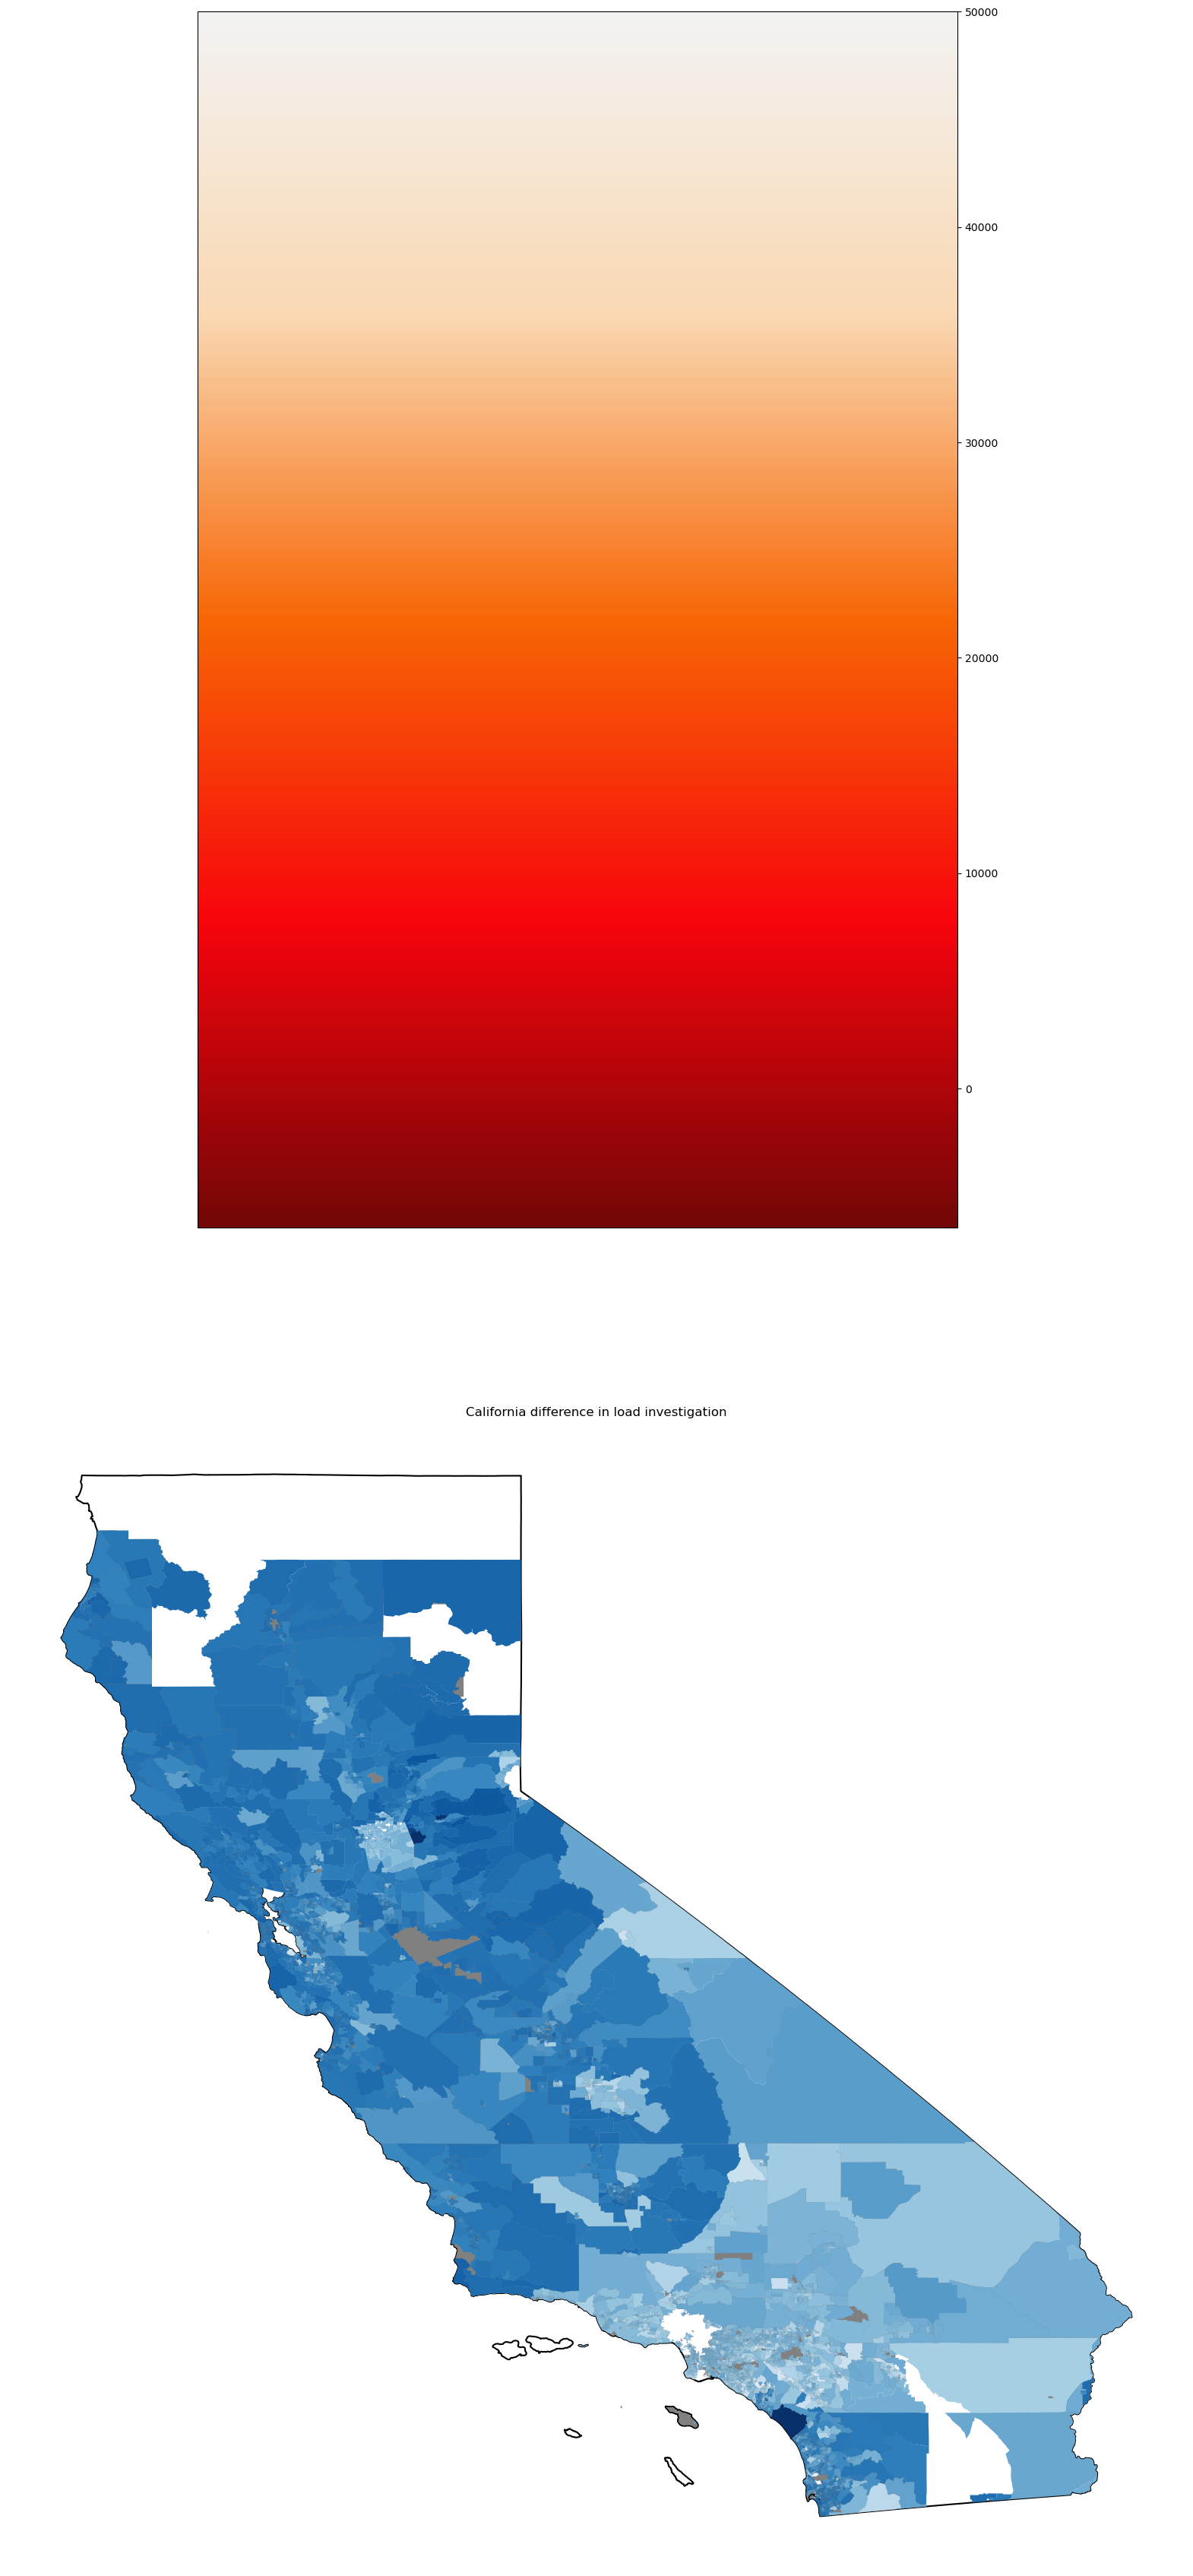

In [75]:
fig, ax = plt.subplots(figsize = (20, 20))
ax.axis('off')

# cmap = plt.get_cmap('Oranges')
# oranges_reversed = cmap.reversed()

ca_boundary.geometry.boundary.plot(ax = ax,
                 zorder = 1, 
                 color = 'black',
                 linewidth = 1.5)

pge_shape.plot(ax = ax,
               zorder = 2,
               color = 'grey')

sce_shape.plot(ax = ax,
               zorder = 3,
               color = 'grey')

sdge_shape.plot(ax = ax, 
           zorder = 4,
           color = 'grey')

sce_join.plot('diff_proj_load',
          ax = ax,
          zorder = 5,
          cmap = blues_cmap, 
          norm = sce_norm)

sdge_join.plot('diff_proj_load',
          ax = ax,
          zorder = 6,
          cmap = blues_cmap,
          norm = sdge_norm)

pge_join.plot('diff_proj_load',
              ax = ax,
              zorder = 7,
              cmap = blues_cmap, 
              norm = pge_norm)



plt.title('California difference in load investigation')

# Add shared colorbar at the bottom
sm = plt.cm.ScalarMappable(norm=plt.Normalize(vmin= min_diff, vmax=max_diff), cmap = orange_cmap)
cbar_ax = fig.add_axes([0.25, 1, 0.5, 0.8])  # [left, bottom, width, height]
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='vertical')
# cbar.set_label('Difference in load to projected load')

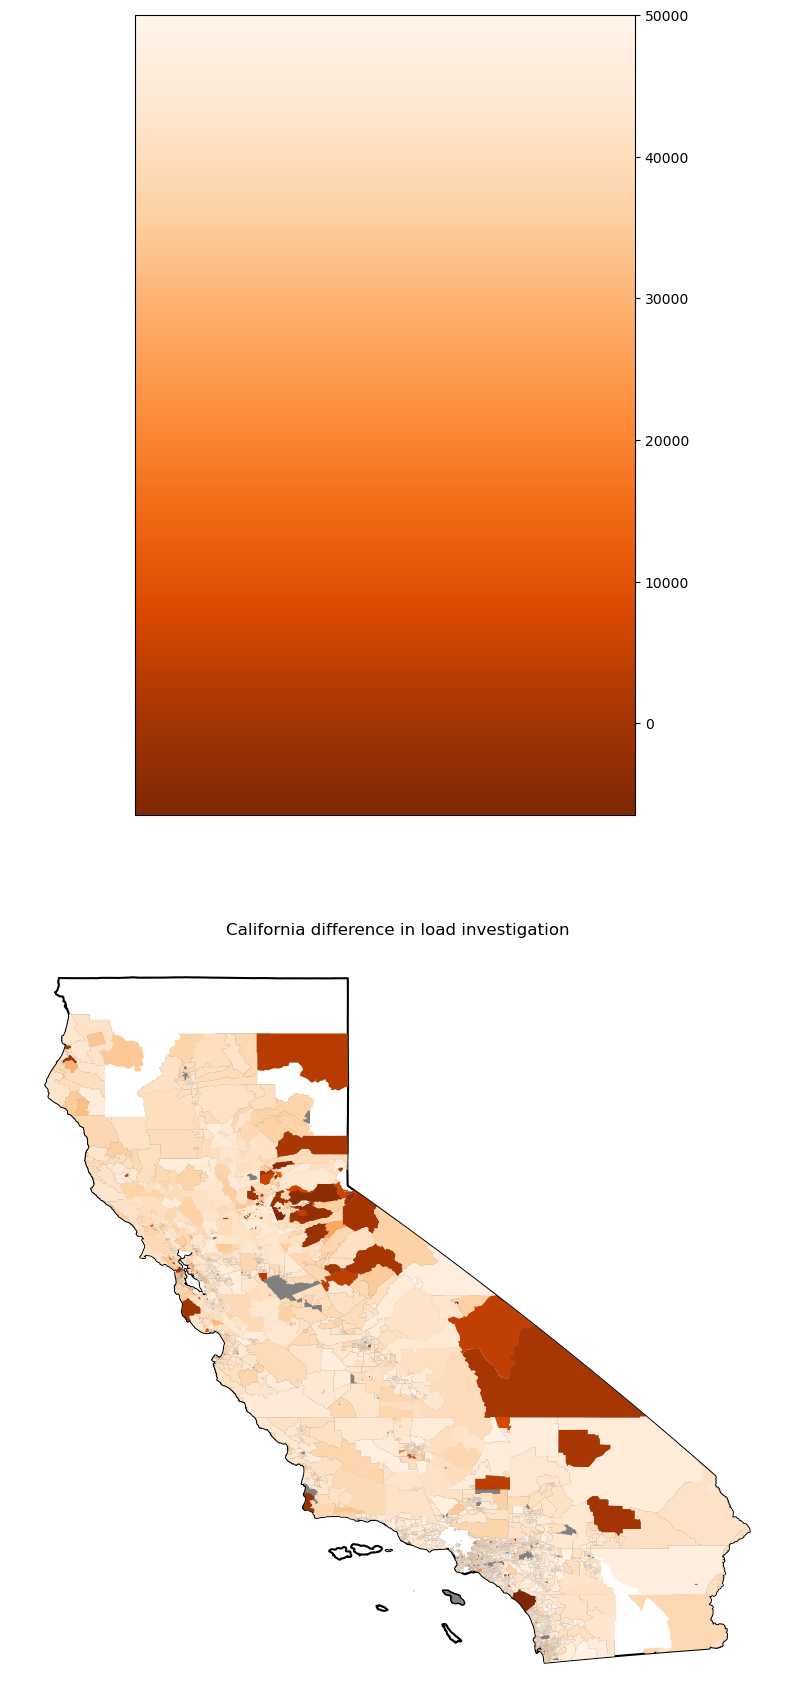

In [43]:
fig, ax = plt.subplots(figsize = (10, 10))
ax.axis('off')

cmap = plt.get_cmap('Oranges')
reversed_cmap = cmap.reversed()

ca_boundary.geometry.boundary.plot(ax = ax,
                 zorder = 1, 
                 color = 'black',
                 linewidth = 1.5)

pge_shape.plot(ax = ax,
               zorder = 2,
               color = 'grey')

sce_shape.plot(ax = ax,
               zorder = 3,
               color = 'grey')

sdge_shape.plot(ax = ax, 
           zorder = 4,
           color = 'grey')

sce_join.plot('transformed_diff_proj_load',
          ax = ax,
          zorder = 5,
          cmap = reversed_cmap)

sdge_join.plot('transformed_diff_proj_load',
          ax = ax,
          zorder = 6,
          cmap = reversed_cmap)

pge_join.plot('transformed_diff_proj_load',
              ax = ax,
              zorder = 7,
              cmap = reversed_cmap)



plt.title('California difference in load investigation')

# Add shared colorbar at the bottom
sm = plt.cm.ScalarMappable(norm=plt.Normalize(vmin= min_diff, vmax=max_diff), cmap = reversed_cmap)
cbar_ax = fig.add_axes([0.25, 1, 0.5, 0.8])  # [left, bottom, width, height]
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='vertical')
# cbar.set_label('Difference in load to projected load')

## Visualize number of census tracts that can meet projected load

Create a binary to visualize the number of census tracts that can meet the projected load.

In [33]:
# create a binary exploring whether the projected load can be met
sce_join['met_proj_load'] = np.where(sce_join['diff_proj_load'] < 0, 0, 1 )
pge_join['met_proj_load'] = np.where(pge_join['diff_proj_load'] < 0, 0, 1 )
sdge_join['met_proj_load'] = np.where(sdge_join['diff_proj_load'] < 0, 0, 1 )

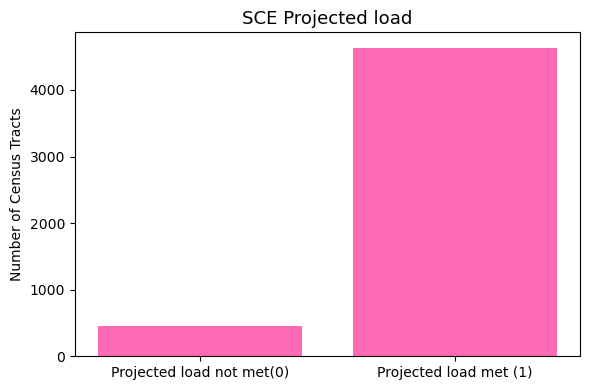

In [34]:
# count census tracts that can meet projected load
counts = sce_join['met_proj_load'].value_counts().sort_index()

labels = ['Projected load not met(0)', 'Projected load met (1)']

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(labels, counts.values, color = 'hotpink')
ax.set_title('SCE Projected load', fontsize=13)
ax.set_ylabel('Number of Census Tracts')
plt.tight_layout()
plt.show()

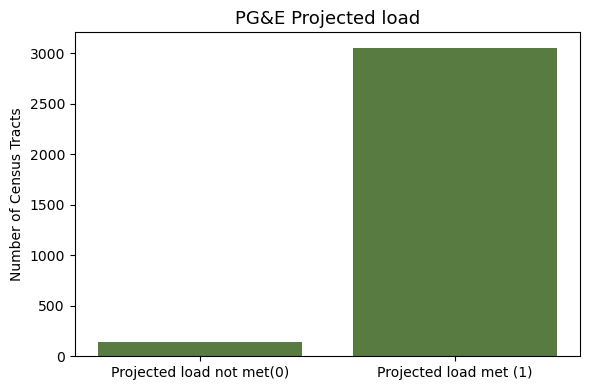

In [35]:
# count census tracts that can meet projected load
counts = pge_join['met_proj_load'].value_counts().sort_index()

labels = ['Projected load not met(0)', 'Projected load met (1)']

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(labels, counts.values, color = '#577B41')
ax.set_title('PG&E Projected load', fontsize=13)
ax.set_ylabel('Number of Census Tracts')
plt.tight_layout()
plt.show()

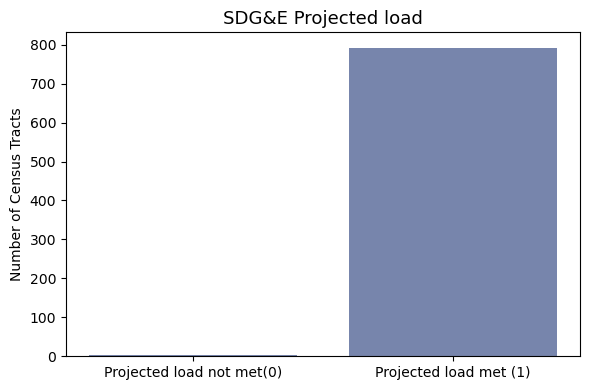

In [36]:
# count census tracts that can meet projected load
counts = sdge_join['met_proj_load'].value_counts().sort_index()

labels = ['Projected load not met(0)', 'Projected load met (1)']

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(labels, counts.values, color = '#7785AC')
ax.set_title('SDG&E Projected load', fontsize=13)
ax.set_ylabel('Number of Census Tracts')
plt.tight_layout()
plt.show()

In [37]:
# concat all of the dataframes to make one visual
iou_projected = gpd.GeoDataFrame(pd.concat([sce_join, pge_join]), crs = sce_join.crs)
iou_projected = gpd.GeoDataFrame(pd.concat([iou_projected, sdge_join]), crs = sdge_join.crs)

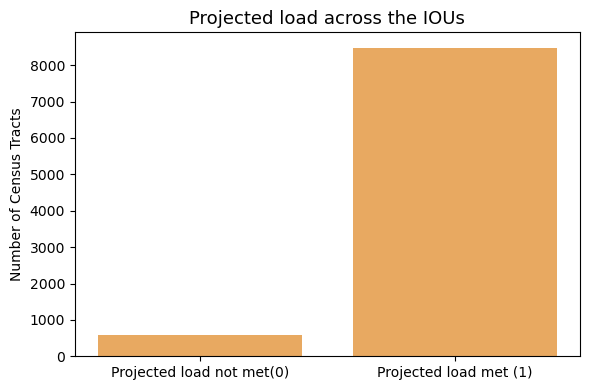

In [38]:
# count census tracts that can meet projected load
counts = iou_projected['met_proj_load'].value_counts().sort_index()

labels = ['Projected load not met(0)', 'Projected load met (1)']

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(labels, counts.values, color = "#E8A961")
ax.set_title('Projected load across the IOUs', fontsize=13)
ax.set_ylabel('Number of Census Tracts')
plt.tight_layout()
plt.show()

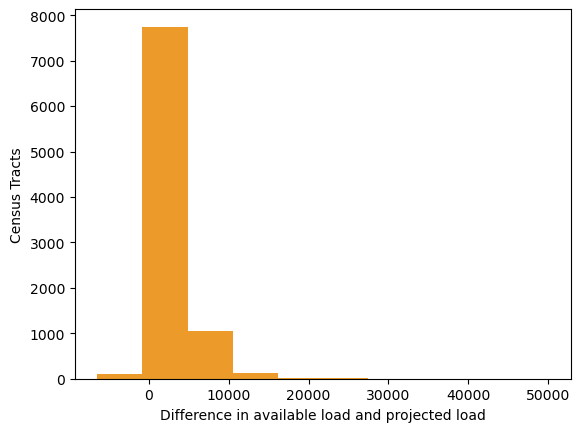

In [39]:
plt.hist(iou_projected['diff_proj_load'],
         color = "#EC9A29")
plt.ylabel("Census Tracts")
plt.xlabel('Difference in available load and projected load')
plt.show()